## Questão 1

N = 100, Estimativa = 0.348743, Erro = 0.037552
N = 1000, Estimativa = 0.386120, Erro = 0.000174
N = 10000, Estimativa = 0.387629, Erro = 0.001335
N = 100000, Estimativa = 0.386992, Erro = 0.000697


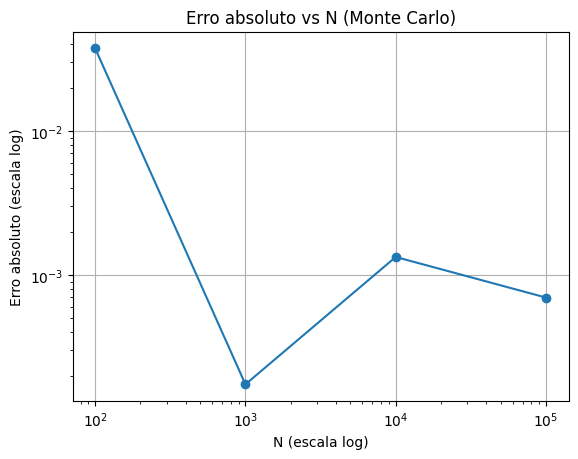

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Valor analítico da integral para o cálculo do erro
I_exato = 2 * np.log(2) - 1

# (b) Tamanhos de amostras solicitados
N_values = [10**2, 10**3, 10**4, 10**5]
erros = []

for N in N_values:
  # Gerar amostras uniformes em [0,1]
  x = np.random.uniform(0, 1, N)

  # Avaliar a função
  f = np.log(1 + x)

  # Estimativa Monte Carlo
  I_est = np.mean(f)

  # Erro absoluto
  erro = abs(I_est - I_exato)
  erros.append(erro)

  print(f"N = {N}, Estimativa = {I_est:.6f}, Erro = {erro:.6f}")

# Plot do erro
plt.figure()
plt.loglog(N_values, erros, marker='o')
plt.xlabel('N (escala log)')
plt.ylabel('Erro absoluto (escala log)')
plt.title('Erro absoluto vs N (Monte Carlo)')
plt.grid(True)
plt.show()


## Questão 2

In [1]:
import numpy as np

# Número de amostras
N = 10**6

# a) Monte Carlo Simples (uniforme)
x_uniform = np.random.uniform(0, 1, N)

f = 1 / (1 + x_uniform)**2
I_mc = np.mean(f)

# b)-c) Importance Sampling

# Amostragem usando inversa da CDF
u = np.random.uniform(0, 1, N)
x_is = 2**u - 1 # transformação inversa

# Peso f(x)/p(x)
# f(x) = 1/(1+x)^2
# p(x) = 1/(ln(2)*(1+x))
#  => peso = ln(2)/(1+x)
weights = np.log(2) / (1 + x_is)

I_is = np.mean(weights)

# Valor exato (para comparação)
# Integral analítica:
# ∫ 1/(1+x)^2 dx = -1/(1+x)
# de 0 a 1 => 1 - 1/2 = 1/2
I_exact = 0.5

# Resultados
print("Monte Carlo simples:", I_mc)
print("Importance Sampling:", I_is)
print("Valor exato:", I_exact)

print("\nErros:")
print("Erro MC:", abs(I_mc - I_exact))
print("Erro IS:", abs(I_is - I_exact))

Monte Carlo simples: 0.4998468383905348
Importance Sampling: 0.5001071945715523
Valor exato: 0.5

Erros:
Erro MC: 0.0001531616094652133
Erro IS: 0.00010719457155228262


## Questão 3

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Número de amostras
N = 100000

samples = []
total = 0
accepted = 0

while len(samples) < N:
  total += 1

  x = np.random.uniform(0, 1)
  u = np.random.uniform(0, 1)

  if u <= x**2:
    samples.append(x)
    accepted += 1

samples = np.array(samples)

# Taxa de aceitação
acceptance_rate = accepted / total

print("Taxa de aceitação:", acceptance_rate)

Taxa de aceitação: 0.3322347437805656


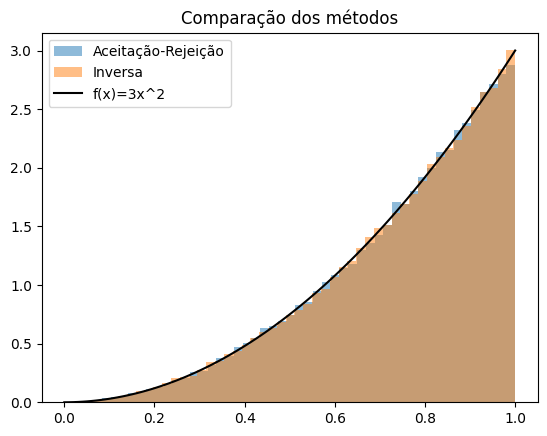

In [6]:
# Método da inversa
u = np.random.uniform(0, 1, N)
samples_inv = u**(1/3)

x_vals = np.linspace(0, 1, 100)
f_vals = 3 * x_vals**2

plt.hist(samples, bins=50, density=True, alpha=0.5, label="Aceitação-Rejeição")
plt.hist(samples_inv, bins=50, density=True, alpha=0.5, label="Inversa")

plt.plot(x_vals, f_vals, 'k-', label="f(x)=3x^2")

plt.legend()
plt.title("Comparação dos métodos")
plt.show()

## Questão 4

In [7]:
import numpy as np

# Número de simulações
N = 10**6

# Baralho: 12 de cada tipo
deck = np.array(['A']*12 + ['B']*12 + ['C']*12 + ['D']*12)

# a) Sem reposição
sucess_no_replacement = 0

for _ in range(N):
  sample = np.random.choice(deck, size=7, replace=False)

  if ('B' in sample) and ('D' in sample):
    sucess_no_replacement += 1

p_no_replacement = sucess_no_replacement / N

# b) Com reposição

sucess_with_replacement = 0

for _ in range(N):
  sample = np.random.choice(deck, size=7, replace=True)

  if ('B' in sample and 'D' in sample):
    sucess_with_replacement += 1

p_with_replacement = sucess_with_replacement / N

# Resultados

print("Sem reposição:", p_no_replacement)
print("Com reposição:", p_with_replacement)

Sem reposição: 0.777538
Com reposição: 0.741169


## Questão 5

(a) Probabilidade estimada por Monte Carlo (100000 simulações): 0.1671 (ou 16.71%)
(b) Probabilidade teórica: 0.1667 (ou 16.67%)
Erro absoluto: 0.000433


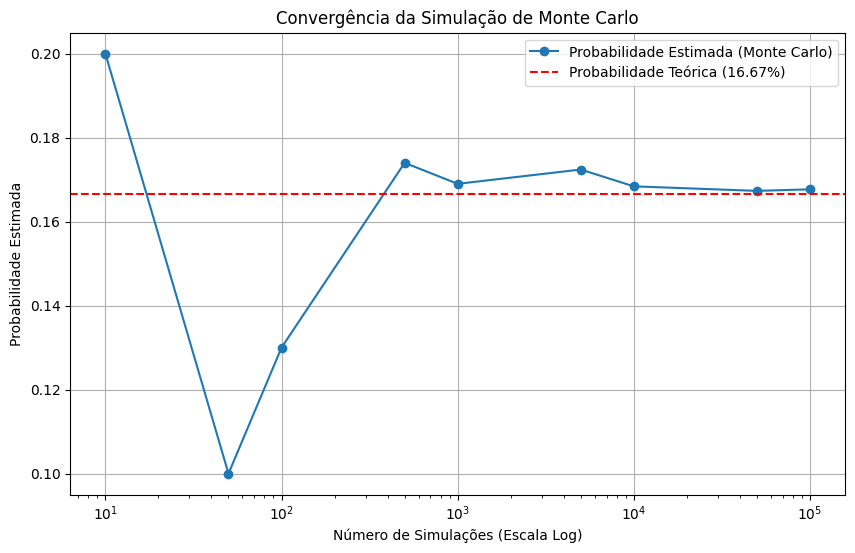

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Simulação de Monte Carlo

def simular_dados(num_simulacoes):
  # Lança dois dados 'num_simulacoes' vezes (valores de 1 a 6)
  dado1 = np.random.randint(1, 7, num_simulacoes)
  dado2 = np.random.randint(1, 7, num_simulacoes)

  # Soma os resultados dos dois dados em cada lançamento
  somas = dado1 + dado2

  #Conta quantas vezes a soma foi estritamente maior que 9 (10, 11 ou 12)
  sucessos = np.sum(somas > 9)

  # Calcula a probabilidade estimada
  probabilidade_estumada = sucessos / num_simulacoes
  return probabilidade_estumada

N = 100000
prob_estimada = simular_dados(N)
print(f"(a) Probabilidade estimada por Monte Carlo ({N} simulações): {prob_estimada:.4f} (ou {prob_estimada*100:.2f}%)")

# b) Valor Teórico

# Espaço amostral total: 6 * 6 = 36 resultados possíveis
# Casos favoráveis (soma > 9):
# Soma 10: (4,6), (5,5), (6,4) -> 3 casos
# Soma 11: (5,6), (6,5) -> 2 casos
# Soma 12: (6,6) -> 1 caso
# Total de casos favoráveis: 3 + 2 + 1 = 6

prob_teorica = 6 / 36
print(f"(b) Probabilidade teórica: {prob_teorica:.4f} (ou {prob_teorica*100:.2f}%)")
print(f"Erro absoluto: {abs(prob_teorica - prob_estimada):.6f}")

# c) Efeito do número de simulações na precisão

tamanhos_simulacao = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
resultados = [simular_dados(n) for n in tamanhos_simulacao]

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(tamanhos_simulacao, resultados, marker='o', linestyle='-', label='Probabilidade Estimada (Monte Carlo)')
plt.axhline(y=prob_teorica, color='r', linestyle='--', label='Probabilidade Teórica (16.67%)')
plt.xscale('log') # Escala logarítmica para visualizar melhor a variação
plt.xlabel('Número de Simulações (Escala Log)')
plt.ylabel('Probabilidade Estimada')
plt.title('Convergência da Simulação de Monte Carlo')
plt.legend()
plt.grid(True)
plt.show()
